In [2]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:

pd.set_option("display.max_rows", None)
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 2000)           # Prevent automatic line wrapping
pd.set_option('display.max_colwidth', None) # Show full column content

In [4]:
# Load all CSV files in the fidelity folder
file_paths = glob.glob("fidelity_2301595/fidelity_*.csv")

dfs = []
for path in file_paths:
    df = pd.read_csv(path)
    dfs.append(df)

# Combine into one DataFrame
all_data = pd.concat(dfs, ignore_index=True)

In [5]:
# Check basic statistics and unique parameter values
all_data.describe()

,k,V0,Omega_max,Delta_start,T_ramp_up,T_sweep,T_ramp_down,fidelity
count,2100.0,2.100000e+03,2.100000e+03,2.100000e+03,2.100000e+03,2.100000e+03,2.100000e+03,2100.000000
mean,4.0,2.513274e+08,1.828407e+07,-2.546186e+07,4.871429e-07,5.019048e-07,4.871429e-07,0.745451
std,0.0,2.980942e-08,3.610275e+05,7.241667e+06,1.002756e-07,1.033143e-07,1.002756e-07,0.038573
min,4.0,2.513274e+08,1.771858e+07,-3.769911e+07,3.300000e-07,3.400000e-07,3.300000e-07,0.556857
25%,4.0,2.513274e+08,1.796991e+07,-3.141593e+07,3.960000e-07,4.080000e-07,3.960000e-07,0.723657
50%,4.0,2.513274e+08,1.828407e+07,-2.513274e+07,4.950000e-07,5.100000e-07,4.950000e-07,0.749297
75%,4.0,2.513274e+08,1.859823e+07,-1.884956e+07,5.610000e-07,5.780000e-07,5.610000e-07,0.769223
max,4.0,2.513274e+08,1.884956e+07,-1.382301e+07,6.600000e-07,6.800000e-07,6.600000e-07,0.828499


In [ ]:
# Conversion factors
T_UNIT = 1e-6          # seconds -> 10^-6 s units
F_UNIT = 2 * np.pi * 1e6   # Hz -> 2π·10^6 Hz (i.e. MHz)

# Convert frequency-like columns to “MHz” units (Ω, Δ, V0)
freq_cols = {"V0": "V0_2PiMHz",
             "Omega_max": "Omega_max_2PiMHz",
             "Delta_start": "Delta_start_2PiMHz"}

for old, new in freq_cols.items():
    all_data[new] = all_data[old] / F_UNIT

# Convert time columns to “×10⁻⁷ s” units
time_cols = {"T_ramp_up": "T_ramp_up_1e-6s",
             "T_sweep": "T_sweep_1e-6s",
             "T_ramp_down": "T_ramp_down_1e-6s"}

for old, new in time_cols.items():
    all_data[new] = all_data[old] / T_UNIT

all_data["T_tot"] = all_data["T_ramp_up_1e-6s"]+all_data["T_sweep_1e-6s"]+all_data["T_ramp_down_1e-6s"]

# Keep only converted columns + fidelity
cols_to_keep = ["k"] + list(freq_cols.values()) + ["T_tot"] + ["fidelity"]
df_conv = all_data[cols_to_keep]

# Sort by fidelity descending for analysis
top_df = df_conv.sort_values("fidelity", ascending=False).reset_index(drop=True)

print(top_df.head(500))

     k  V0_2PiMHz  Omega_max_2PiMHz  Delta_start_2PiMHz  T_tot  fidelity
0    4       40.0              3.00                -4.0    1.0  0.828499
1    4       40.0              2.98                -4.0    1.0  0.827965
2    4       40.0              3.00                -4.2    1.0  0.827827
3    4       40.0              3.00                -3.8    1.0  0.827623
4    4       40.0              2.96                -4.0    1.0  0.827310
5    4       40.0              2.98                -4.2    1.0  0.827253
6    4       40.0              2.98                -3.8    1.0  0.827041
7    4       40.0              2.96                -4.2    1.0  0.826565
8    4       40.0              2.94                -4.0    1.0  0.826531
9    4       40.0              2.96                -3.8    1.0  0.826315
10   4       40.0              2.94                -4.2    1.0  0.825758
11   4       40.0              2.92                -4.0    1.0  0.825625
12   4       40.0              2.94                

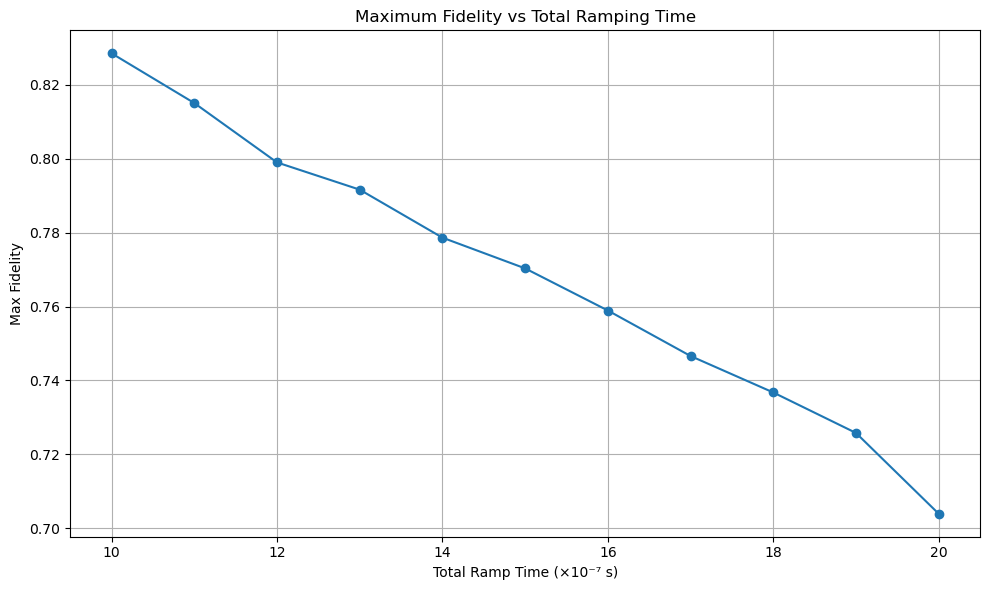

In [7]:
# Compute total ramping time in units of 1e-7 seconds
all_data["T_total_1e-7s"] = (
    all_data["T_ramp_up"] + all_data["T_sweep"] + all_data["T_ramp_down"]
) * 1e7  # convert to 1e-7s unit

# Group by total ramp time and get the row with the max fidelity for each group
best_per_ramp = all_data.loc[all_data.groupby("T_total_1e-7s")["fidelity"].idxmax()]

# Sort by ramp time for proper line plot
best_per_ramp = best_per_ramp.sort_values("T_total_1e-7s")

# Plot line plot
plt.figure(figsize=(10, 6))
plt.plot(best_per_ramp["T_total_1e-7s"], best_per_ramp["fidelity"], marker='o', linestyle='-')
plt.xlabel("Total Ramp Time (×10⁻⁷ s)")
plt.ylabel("Max Fidelity")
plt.title("Maximum Fidelity vs Total Ramping Time")
plt.grid(True)
plt.tight_layout()
plt.show()

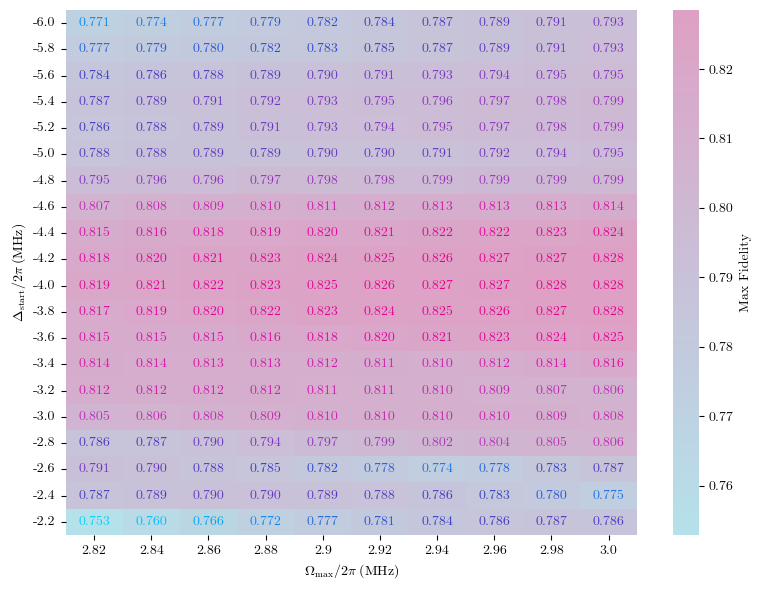

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import colorsys
from matplotlib.colors import Normalize

# Maximize fidelity over T_tot for each (Delta, Omega) pair
max_fidelity = (
    all_data.groupby(["Delta_start_2PiMHz", "Omega_max_2PiMHz"])["fidelity"]
    .max()
    .reset_index()
)
max_fidelity["Delta_start_2PiMHz"] = max_fidelity["Delta_start_2PiMHz"].round(3)
max_fidelity["Omega_max_2PiMHz"] = max_fidelity["Omega_max_2PiMHz"].round(3)

# Pivot the result to form a heatmap table
heatmap_data = max_fidelity.pivot(
    index="Delta_start_2PiMHz", columns="Omega_max_2PiMHz", values="fidelity"
)
from matplotlib.colors import LinearSegmentedColormap

# ————— Plot style ————— #
# Use Computer Modern Unicode (CMU) if available; otherwise fall back to generic serif.
plt.rcParams["font.family"] = ["CMU Serif", "serif"]
plt.rcParams["mathtext.fontset"] = "cm"   # keep LaTeX math in CM

two_tone = LinearSegmentedColormap.from_list(
    "blue_red_pretty",
    [
        "#B4E1EA",  # cool blue
        "#DEA0C5",  # warm magenta-red
    ],
    N=256,       # smooth gradient
)


def saturate(rgb, factor=1.5):
    """Increase saturation of an RGB color by a given factor (clip at 1)."""
    h, l, s = colorsys.rgb_to_hls(*rgb)
    s = min(1, s * factor)  # cap saturation at 1
    return colorsys.hls_to_rgb(h, l, s)

def darker(rgb, factor=0.7):
    """Return an RGB tuple that’s `factor` times the original lightness (HLS)."""
    h, l, s = colorsys.rgb_to_hls(*rgb)
    return colorsys.hls_to_rgb(h, max(0, l * factor), s)

# ————— Heat-map ————— #
plt.figure(figsize=(8, 6))
norm = Normalize(vmin=heatmap_data.min().min(), vmax=heatmap_data.max().max())

ax = sns.heatmap(
    heatmap_data,
    annot=False,
    cmap=two_tone,
    cbar_kws={"label": "Max Fidelity"},
    norm=norm,
)

# manually annotate with saturated text colors
for (row_idx, col_idx), val in np.ndenumerate(heatmap_data.values):
    if np.isnan(val):
        continue
    r, g, b, _ = two_tone(norm(val))  # colormap value
    r_s, g_s, b_s = darker(saturate((r, g, b), factor=2.5), factor=0.6)  # saturate RGB
    ax.text(
        col_idx + 0.5, row_idx + 0.5, f"{val:.3f}",
        ha="center", va="center",
        color=(r_s, g_s, b_s),
        fontsize=10
    )

# tidy axes
ax.set_xticks(np.arange(len(heatmap_data.columns)) + 0.5)
ax.set_yticks(np.arange(len(heatmap_data.index)) + 0.5)
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticklabels(heatmap_data.index)
plt.xticks(rotation=0); plt.yticks(rotation=0)

# titles / labels
plt.xlabel(r"$\Omega_{\max}/2\pi\;(\text{MHz})$")
plt.ylabel(r"$\Delta_{\text{start}}/2\pi\;(\text{MHz})$")
plt.tight_layout()
plt.savefig("../../../writeup/src/fidelity_heatmap.pdf", format="pdf")
plt.show()


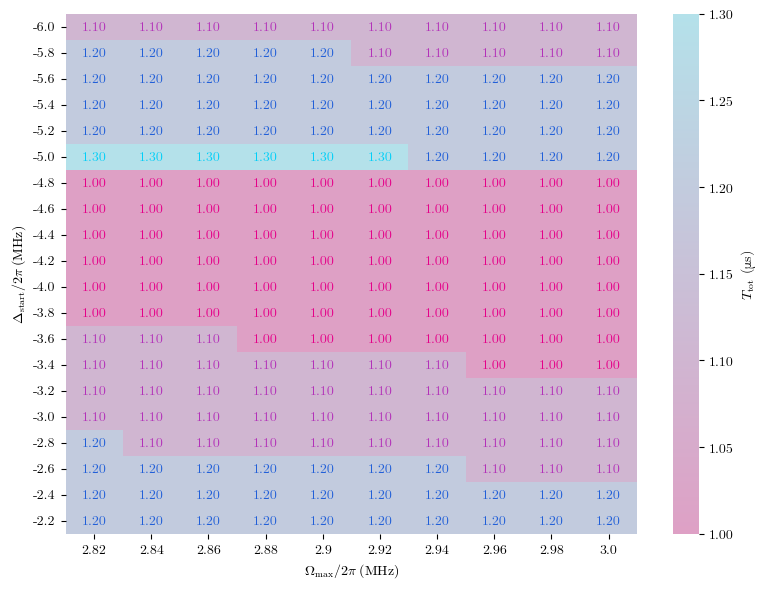

In [ ]:
two_tone = LinearSegmentedColormap.from_list(
    "blue_red_pretty",
    [
        "#DEA0C5",  # warm magenta-red
        "#B4E1EA",  # cool blue
    ],
    N=256,       # smooth gradient
)

# Create a DataFrame showing the T_tot that gave max fidelity for each (Delta, Omega) pair
idxmax = all_data.groupby(["Delta_start_2PiMHz", "Omega_max_2PiMHz"])["fidelity"].idxmax()
best_ttot = all_data.loc[idxmax, ["Delta_start_2PiMHz", "Omega_max_2PiMHz", "T_tot"]].copy()

# Round axes values
best_ttot["Delta_start_2PiMHz"] = best_ttot["Delta_start_2PiMHz"].round(3)
best_ttot["Omega_max_2PiMHz"] = best_ttot["Omega_max_2PiMHz"].round(3)

# Pivot to create the heatmap matrix
ttot_heatmap = best_ttot.pivot(index="Delta_start_2PiMHz", columns="Omega_max_2PiMHz", values="T_tot")

# Plot
plt.figure(figsize=(8, 6))
norm = Normalize(vmin=ttot_heatmap.min().min(), vmax=ttot_heatmap.max().max())
ax = sns.heatmap(
    ttot_heatmap,
    annot=False,
    cmap=two_tone,
    cbar_kws={"label": r"$T_{\text{tot}}$ (μs)"},
    norm=norm,
)

# Annotate manually with color-adjusted text
for (row_idx, col_idx), val in np.ndenumerate(ttot_heatmap.values):
    if np.isnan(val):
        continue
    r, g, b, _ = two_tone(norm(val))
    r_s, g_s, b_s = darker(saturate((r, g, b), factor=2.5), factor=0.6)
    ax.text(
        col_idx + 0.5, row_idx + 0.5, f"{val:.2f}",
        ha="center", va="center",
        color=(r_s, g_s, b_s),
        fontsize=10
    )

# Axis labels and formatting
ax.set_xticks(np.arange(len(ttot_heatmap.columns)) + 0.5)
ax.set_yticks(np.arange(len(ttot_heatmap.index)) + 0.5)
ax.set_xticklabels(ttot_heatmap.columns)
ax.set_yticklabels(ttot_heatmap.index)
plt.xticks(rotation=0); plt.yticks(rotation=0)

plt.xlabel(r"$\Omega_{\max}/2\pi\;(\text{MHz})$")
plt.ylabel(r"$\Delta_{\text{start}}/2\pi\;(\text{MHz})$")
plt.tight_layout()
plt.savefig("../../writeup/src/ttot_optimal_heatmap.pdf", format="pdf")
plt.show()
